#[Baseline] Data Analysis Competition: NFL Draft Prediction

In this notebook, you will build a **baseline model** for the task of predicting whether a player will be selected in the NFL Draft (**Drafted**) based on sports performance test results and player information.

A baseline model is a simple initial model built for a given machine learning task. It serves as a starting point for further model development and performance improvements.

By running this notebook from top to bottom, you will generate a prediction file that can be submitted successfully.

##Table of Contents
1. Setup

2. Load the Data

3. Data Analysis & EDA

4. Preprocessing

5. Baseline Model

6. Hypothesis & Feature Engineering

7. Create the Submission File

8. Next Steps

## 1.Setup

In [875]:
# Import modules
import numpy as np  # Library for numerical computing and array operations
import pandas as pd  # Library for handling tabular data
import matplotlib.pyplot as plt  # Library for basic data visualization
import seaborn as sns  # Library for statistical data visualization
from sklearn.preprocessing import LabelEncoder, StandardScaler  # Encoder for converting categorical variables to numeric labels
from sklearn.ensemble import RandomForestClassifier  # Random Forest classifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV  # Class for stratified K-fold cross-validation
from sklearn.metrics import roc_auc_score  # Metric function for computing ROC AUC

In this notebook, we assume the following directory structure in your Google Drive:
```
MyDrive/
└── GCI/
    └── competition/
        ├──README.ipynb
        ├── baseline.ipynb  # This notebook (baseline)
        └── input/
            ├── train.csv  # Training data
            ├── test.csv  # Test data (for prediction)
            └── sample_submission.csv  # Sample submission file

```

## 2.Load the data

### 2.1 Connect with Google Drive
To load the data, we first need to connect this Colab notebook with Google Drive.

In [876]:
# If you work with Google Colaboratory, please run this as well.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Next, we need to navigate to where the `competition` folder is located

**IMPORTANT**:<br>
Change the path in the `%cd` command below to match the folder where this notebook is saved on Google Drive by **replacing "WhereThisNotebookIsLocated" with your actual folder path**.

Examples:
- You uploaded `competition` folder directly under MyDrive (the default folder when you open Google Drive)
    - Change to "/<wbr>content/drive/MyDrive/competition"
- You uploaded `competition` folder inside a folder named `00_GCIGlobal` under MyDrive
    - Change to "/<wbr>content/drive/MyDrive/00_GCIGlobal/competition"

You can easily locate your notebook's directory by:
1. Open the Files panel on the left side of Colab
2. Navigate through the "drive" and "MyDrive" folders until you find your notebook's folders
3. Click the more actions icon (three vertical dots, $\vdots$) next to the folder name
4. Select the option "Copy path"

In [877]:
# Specify the directory where this notebook is located after %cd.
%cd "/content/drive/MyDrive/GCI 2026/competition"

/content/drive/MyDrive/GCI 2026/competition


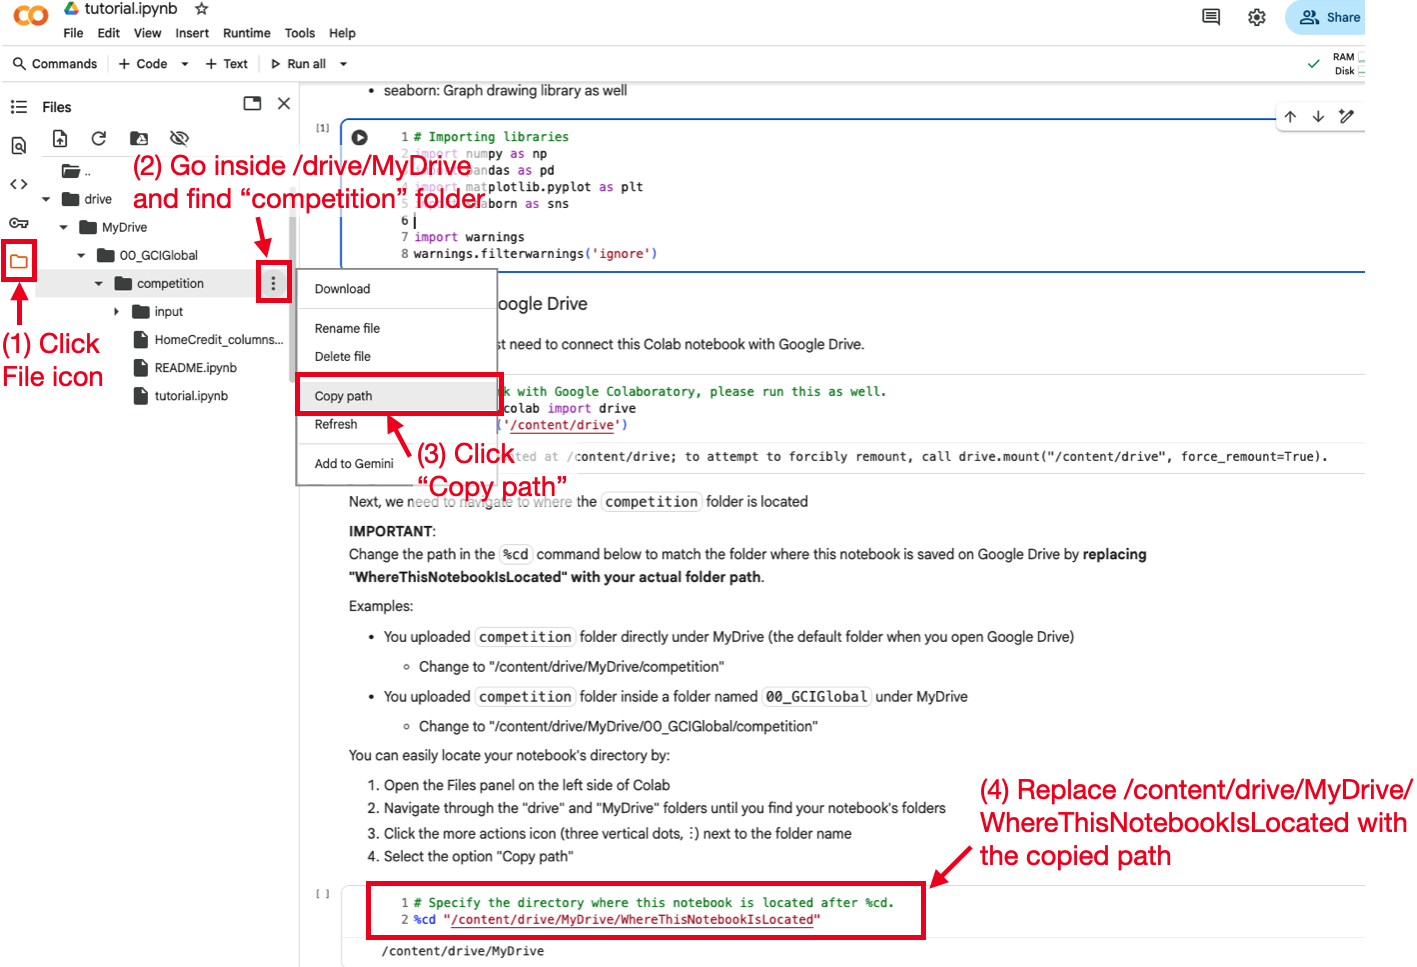

Run the cell below to check if the path is correctly set.

In [878]:
from pathlib import Path

PATH = Path.cwd() / "input"

train_file = PATH / "train.csv"
test_file = PATH / "test.csv"
sample_sub_file = PATH / "sample_submission.csv"

# Check if path exists
if train_file.exists() and test_file.exists() and sample_sub_file.exists():
    print("All files exist and path is correctly set.")
else:
    print("Some files are missing or path is not correctly set.")

All files exist and path is correctly set.


### 2.2 Data Overview
Run the cell to load the dataset as `pd.DataFrame`.

**IMPORTANT:**<br>
**When you make modifications to preprocessing or model training, always make sure to run all cells from this cell.**

In [879]:
PATH = Path.cwd() / "input"

train = pd.read_csv(PATH / "train.csv")
test = pd.read_csv(PATH / "test.csv")
sample_sub = pd.read_csv(PATH / "sample_submission.csv")

print(f"train: {train.shape}, test: {test.shape}, sample_sub: {sample_sub.shape}")

train: (2781, 16), test: (696, 15), sample_sub: (696, 2)


First, let's check the shape of the dataset.

In [880]:
print('Train:', train.shape)
print('Test:', test.shape)

Train: (2781, 16)
Test: (696, 15)


We can see that the training data contains **2,781 rows** and **16 columns**, while the test data contains **696 rows** and **15 columns**.
The test data has one fewer column because it does not include the target variable to be predicted.

Next, let's take a look at the **first five rows** of the training data.

In [881]:
train.head()

,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


In [882]:
test.head()

,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position
0,2781,2017,22.0,Pittsburgh,1.9558,136.077711,5.27,76.20,21.0,289.56,8.39,5.09,offense,offensive_lineman,OG
1,2782,2013,22.0,William & Mary,1.7780,83.460996,4.51,102.87,14.0,335.28,6.82,3.84,defense,defensive_back,CB
2,2783,2018,21.0,Alabama,1.8542,103.419060,4.52,101.60,14.0,327.66,NaN,4.34,offense,backs_receivers,RB
3,2784,2009,21.0,Georgia,1.8034,98.429544,4.50,90.17,25.0,292.10,6.84,4.27,offense,backs_receivers,RB
4,2785,2018,23.0,Alabama,1.8288,83.914588,4.36,80.01,13.0,302.26,6.93,4.40,defense,defensive_back,CB


In [883]:
train.dtypes

,0
Id,int64
Year,int64
Age,float64
School,object
Height,float64
Weight,float64
Sprint_40yd,float64
Vertical_Jump,float64
Bench_Press_Reps,float64
Broad_Jump,float64


You can view detailed information about a pandas DataFrame by using `.info()`.

In [884]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2781 entries, 0 to 2780
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                2781 non-null   int64  
 1   Year              2781 non-null   int64  
 2   Age               2346 non-null   float64
 3   School            2781 non-null   object 
 4   Height            2781 non-null   float64
 5   Weight            2781 non-null   float64
 6   Sprint_40yd       2636 non-null   float64
 7   Vertical_Jump     2227 non-null   float64
 8   Bench_Press_Reps  2060 non-null   float64
 9   Broad_Jump        2200 non-null   float64
 10  Agility_3cone     1811 non-null   float64
 11  Shuttle           1869 non-null   float64
 12  Player_Type       2781 non-null   object 
 13  Position_Type     2781 non-null   object 
 14  Position          2781 non-null   object 
 15  Drafted           2781 non-null   float64
dtypes: float64(10), int64(2), object(4)
memory

### [Next Steps]

This section only loaded the data. A few easy starting points to dig deeper before EDA:

- Run `train.describe()` and `test.describe()` to see summary statistics for the numerical columns.
- Check for duplicate rows with `train.duplicated().sum()`.
- Compare basic statistics (mean, std, min, max) between **train** and **test** to check whether the two splits look similar.

In [885]:
train.describe()

,Id,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Drafted
count,2781.000000,2781.000000,2346.000000,2781.000000,2781.000000,2636.000000,2227.000000,2060.000000,2200.000000,1811.000000,1869.000000,2781.000000
mean,1390.000000,2013.838907,21.997016,1.873590,109.502026,4.764818,83.506349,20.236408,291.985700,7.230447,4.399422,0.648328
std,802.949874,3.083247,0.964836,0.067178,20.307239,0.299343,10.710691,6.410662,23.924666,0.410686,0.263851,0.477578
min,0.000000,2009.000000,18.000000,1.651000,67.585263,4.220000,44.450000,2.000000,198.120000,6.280000,3.820000,0.000000
25%,695.000000,2011.000000,21.000000,1.828800,92.986436,4.530000,76.200000,16.000000,276.860000,6.930000,4.200000,0.000000
50%,1390.000000,2014.000000,22.000000,1.879600,104.779837,4.680000,83.820000,20.000000,294.640000,7.130000,4.350000,1.000000
75%,2085.000000,2017.000000,23.000000,1.930400,124.284309,4.950000,91.440000,24.000000,307.340000,7.490000,4.560000,1.000000
max,2780.000000,2019.000000,28.000000,2.082800,162.386068,6.000000,114.300000,45.000000,373.380000,9.040000,5.560000,1.000000


In [886]:
test.describe()

,Id,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle
count,696.000000,696.000000,581.000000,696.000000,696.000000,667.000000,553.000000,512.000000,549.000000,449.000000,468.000000
mean,3128.500000,2013.762931,21.927711,1.875476,110.722810,4.785922,82.933526,20.259766,290.203097,7.265523,4.421496
std,201.062179,3.046376,0.986953,0.068770,21.161295,0.309420,10.544504,6.842719,24.074513,0.407634,0.270203
min,2781.000000,2009.000000,19.000000,1.676400,76.657111,4.280000,52.070000,6.000000,210.820000,6.500000,3.810000
25%,2954.750000,2011.000000,21.000000,1.828800,92.986436,4.540000,74.930000,15.000000,276.860000,6.980000,4.220000
50%,3128.500000,2014.000000,22.000000,1.879600,104.779837,4.700000,83.820000,20.000000,294.640000,7.180000,4.380000
75%,3302.250000,2016.000000,23.000000,1.930400,131.995380,5.005000,90.170000,25.000000,307.340000,7.500000,4.592500
max,3476.000000,2019.000000,27.000000,2.032000,167.375585,5.760000,111.760000,49.000000,345.440000,8.720000,5.380000


In [887]:
test.duplicated().sum()

np.int64(0)

## 3.Data Analysis & EDA

**EDA (Exploratory Data Analysis)** is an essential step for understanding the structure and characteristics of your data before building a model.

At this stage, you explore trends and patterns in the dataset, as well as **outliers**, **missing values**, and **imbalanced distributions**. For example, some variables may contain extreme values, or the data may be heavily skewed toward specific categories. Identifying these characteristics helps you find potential issues that could hurt performance and uncover features that may be useful for prediction.

By performing EDA, you can detect and address problems early—such as “training fails due to missing values” or “the model becomes unstable because of outliers.” This reduces rework later and enables more efficient preprocessing and feature engineering.

Insights from EDA also inform later decisions, including model selection and hyperparameter tuning. In machine learning competitions, EDA is often a key process for improving final scores.

### 3.1 Checking Missing Values

First, let's check for missing values. This is an essential step in machine-learning-based data analysis, because most machine learning models cannot train on or make predictions from data that contains missing values, and will raise an error.

In [888]:
train.isnull().sum()

,0
Id,0
Year,0
Age,435
School,0
Height,0
Weight,0
Sprint_40yd,145
Vertical_Jump,554
Bench_Press_Reps,721
Broad_Jump,581


In [889]:
test.isnull().sum()

,0
Id,0
Year,0
Age,115
School,0
Height,0
Weight,0
Sprint_40yd,29
Vertical_Jump,143
Bench_Press_Reps,184
Broad_Jump,147


We found missing values in the following columns: **Age**,**Sprint_40yd**, **Vertical_Jump**, **Bench_Press_Reps**, **Broad_Jump**, **Agility_3cone**, and **Shuttle**. We will handle these later.

### 3.2 Visualization and Analysis

Next, let's look at how many players were drafted.

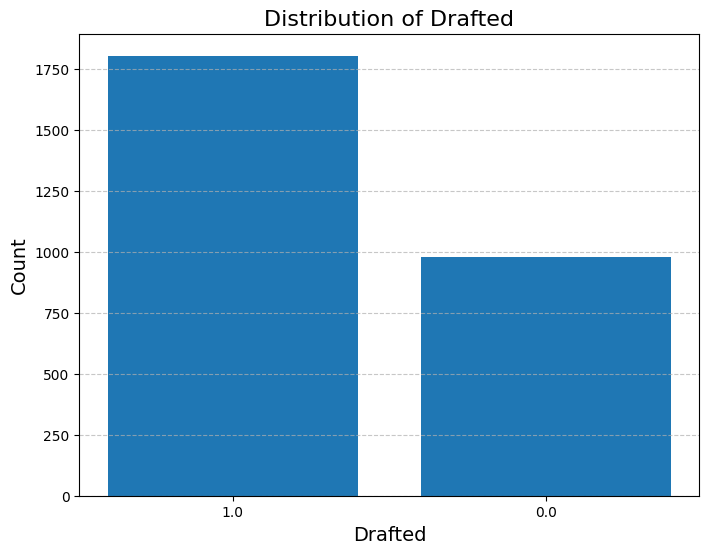

In [890]:
drafted_counts = train['Drafted'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(drafted_counts.index.astype(str), drafted_counts.values)
plt.title('Distribution of Drafted', fontsize=16)
plt.xlabel('Drafted', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

We can see that there are more players with **Drafted = 1** than those with **Drafted = 0**. Let's check the propotions.

In [891]:
drafted_percentage = train['Drafted'].value_counts(normalize=True) * 100

print(f"Percentage of 0: {drafted_percentage.get(0, 0):.2f}%")
print(f"Percentage of 1: {drafted_percentage.get(1, 0):.2f}%")

Percentage of 0: 35.17%
Percentage of 1: 64.83%


We found that about **35%** of the players were **not drafted**, while about **65%** were **drafted**.

Next, we will continue EDA for the other features. First, let's visualize the numerical variables excluding the **"Id"** and **"Drafted"** columns.

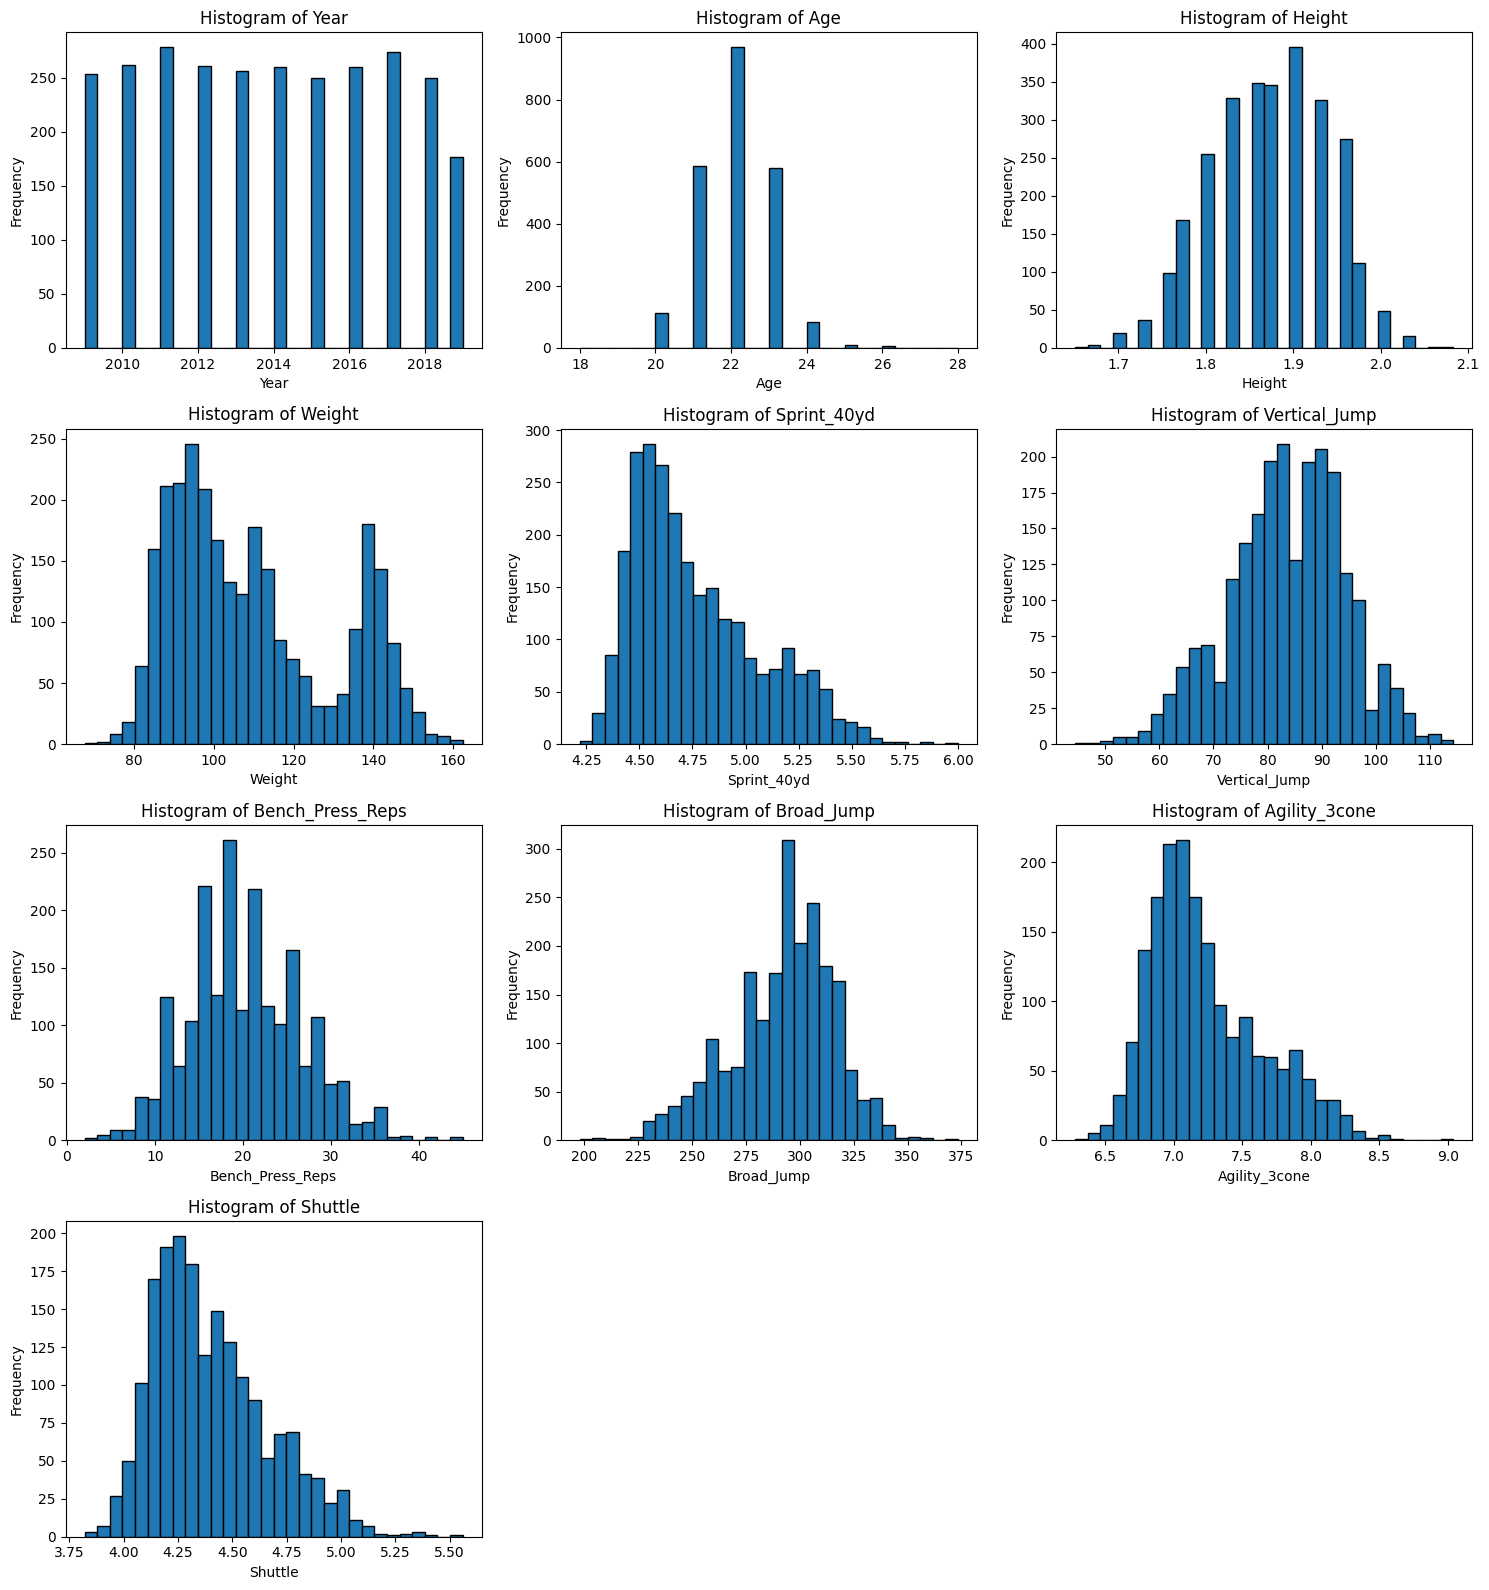

In [892]:
# Extraxt numeric columns (excluding the 'Id' and 'Drafted' columns)
numeric_cols = train.select_dtypes(include=['number']).columns
numeric_cols = numeric_cols.drop(['Id', 'Drafted'])

# Plot
num_cols = len(numeric_cols)
cols = 3
rows = (num_cols + cols - 1) // cols

plt.figure(figsize=(5 * cols, 4 * rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    plt.hist(train[col].dropna(), bins=30, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Let's examine the correlation matrix of the numerical features using a heatmap.

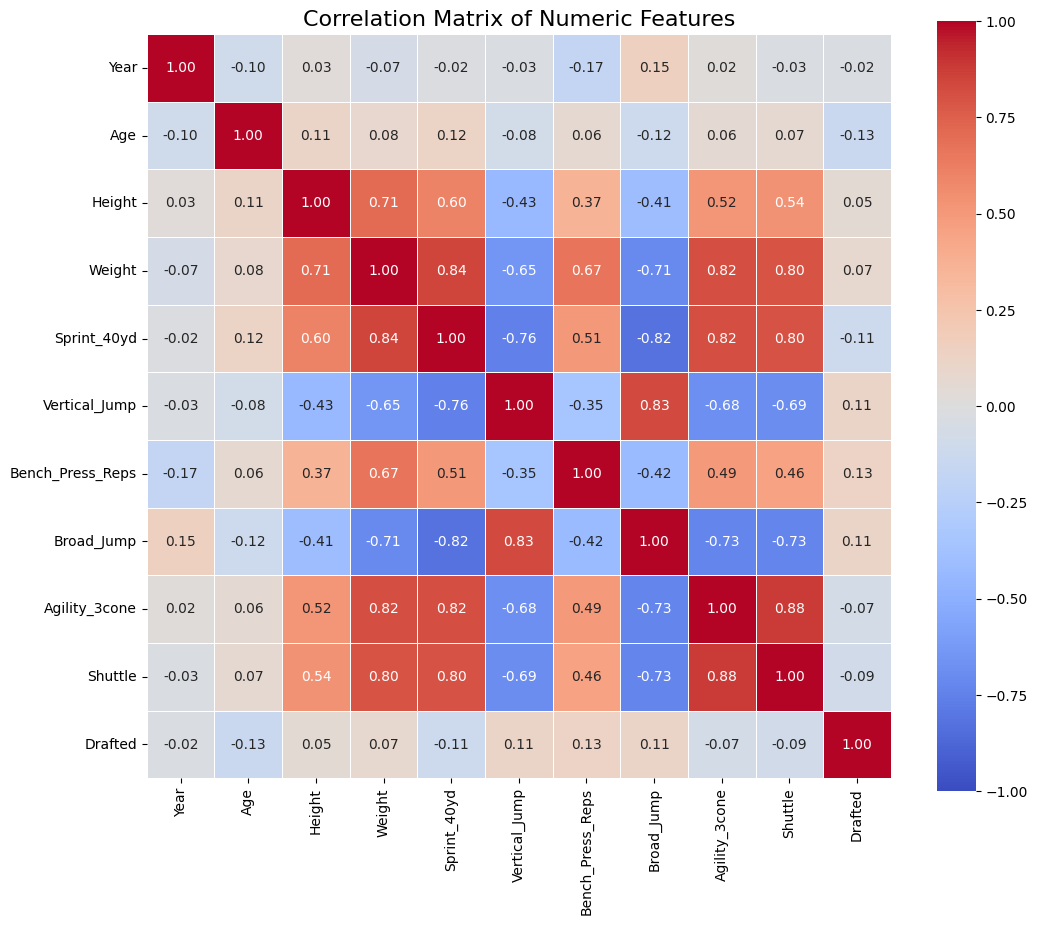

In [893]:
# Extract numeric columns (excluding the 'Id' and ''Drafted' columns)
numeric_cols = train.select_dtypes(include=['number']).drop(['Id'], axis=1)

# Compute the correlation matrix
corr_matrix = numeric_cols.corr()

# Plot a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.show()

The correlation coefficient between **Agility_3cone** and **Shuttle** is **0.88**, indicating a strong positive relationship. These tests may rely on similar muscle groups and movement patterns.

On the other hand, the correlation coefficient between **Sprint_40yd** and **Broad_Jump** is **-0.82**, showing a strong negative relationship. Since both events mainly depend on lower-body power, we might normally expect their scores to move together (i.e., a positive correlation), but here we observe the opposite. To investigate this further, let’s visualize **Sprint_40yd**.

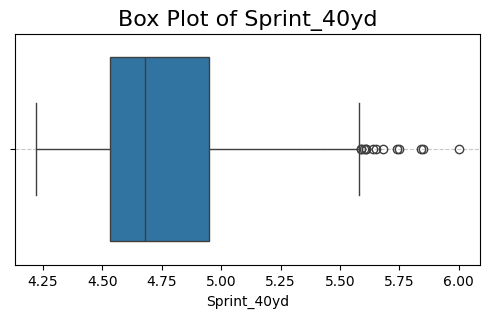

In [894]:
# Plot a boxplot
plt.figure(figsize=(6, 3))
sns.boxplot(x=train['Sprint_40yd'])

plt.title('Box Plot of Sprint_40yd', fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

From the plot, we can see that values in **Sprint_40yd** are roughly distributed between **4.25** and **6.00**. This suggests the column likely represents the **actual sprint time**, not a “score.” A median of around **4.7 seconds** is reasonable for a 40-yard (about 36-meter) dash.

In other words, **smaller values** in **Sprint_40yd** mean faster times, so **lower is better**—the opposite direction from metrics where **higher values indicate better performance**. This explains why we observed a negative correlation with **Broad_Jump**.

By visualizing the data, we were able to answer the question: **“Why is there a negative correlation?”**

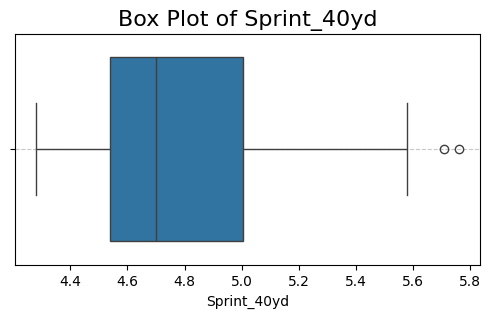

In [895]:
# Plot a boxplot
plt.figure(figsize=(6, 3))
sns.boxplot(x=test['Sprint_40yd'])

plt.title('Box Plot of Sprint_40yd', fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Next, let's visualize the categorical features.

In [896]:
# Extract categorical features
categorical_cols = train.select_dtypes(include=['object', 'category']).columns

# Get the number of unique categories in each column
levels_count = {col: train[col].nunique() for col in categorical_cols}

for col, count in levels_count.items():
    print(f"{col}: {count} levels")


School: 236 levels
Player_Type: 3 levels
Position_Type: 7 levels
Position: 20 levels


**'School'** has **236** unique values, which is too many to visualize clearly, so we will exclude it from the plots here.

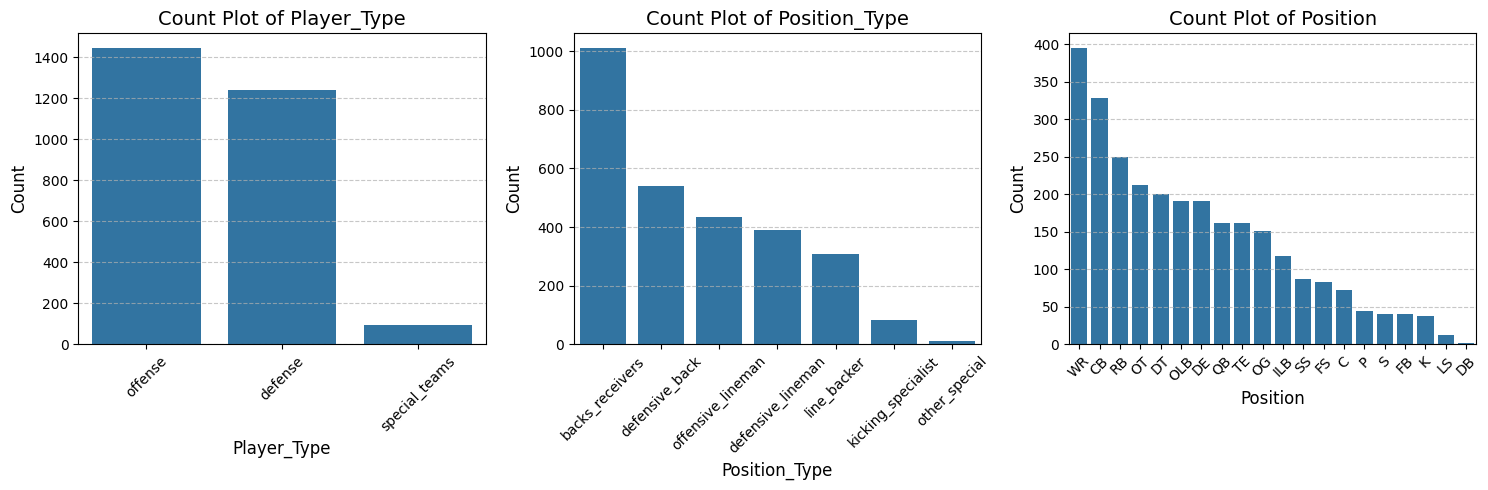

In [897]:
# Extract categorical features (object or category) and exclude the 'School' columns
categorical_cols = train.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop('School')

# Prepare for plotting
num_cols = len(categorical_cols)
rows = 1
cols = num_cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5))

if cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Count plots for each categorical features
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=train, order=train[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

We can see that the number of samples varies widely across categories. For example, in the **Player_Type** column, the **special_teams** category has very few samples.

Next, let's visualize the **mean value of "Drafted"** for each category level. This helps us understand, visually, which positions are more likely to be drafted.

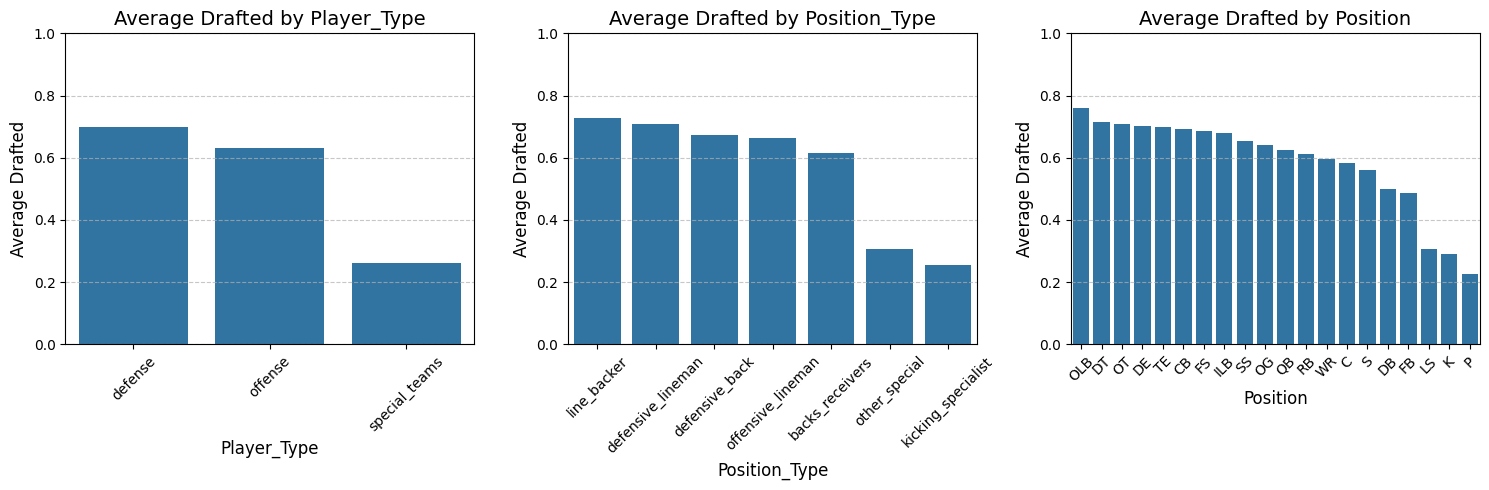

In [898]:
# Extract categorical features (object or category) and exclude the 'School' column
categorical_cols = train.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop('School')

# Prepare for plotting
num_cols = len(categorical_cols)
rows = 1
cols = num_cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5))

if cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Plot the mean value of 'Drafted' for each categorical feature as bar charts
for i, col in enumerate(categorical_cols):
    mean_values = train.groupby(col)['Drafted'].mean().sort_values(ascending=False)
    sns.barplot(x=mean_values.index, y=mean_values.values, ax=axes[i])
    axes[i].set_title(f'Average Drafted by {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Average Drafted', fontsize=12)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


We can see that players with **Player_Type = "special_teams"** have a much lower draft rate than other players.
Similarly, players with **Position_Type = "other_special"** or **"kicking_specialist"**, and those with **Position = "LS"**, **"K"**, or **"P"**, also have relatively low draft rates.

In [899]:
"""#Vamos a corregir la asimetria de las columnas Weight, Sprint_40yd, Agility_3cone y Shuttle.
# Variables con asimetría positiva
cols_skewed = ['Weight', 'Sprint_40yd', 'Agility_3cone', 'Shuttle']

# Aplicar transformación logarítmica (log natural)
for col in cols_skewed:
    # Evitar errores si hay valores <= 0
    train[f'{col}_log'] = np.log(train[col].clip(lower=1e-6))
    test[f'{col}_log'] = np.log(test[col].clip(lower=1e-6))

# Visualizar antes y después
fig, axes = plt.subplots(len(cols_skewed), 2, figsize=(10, 12))
for i, col in enumerate(cols_skewed):
    sns.histplot(train[col], bins=30, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'Original: {col}')
    sns.histplot(train[f'{col}_log'], bins=30, ax=axes[i, 1], color='darkorange')
    axes[i, 1].set_title(f'Log-transformado: {col}')
plt.tight_layout()
plt.show()"""

"#Vamos a corregir la asimetria de las columnas Weight, Sprint_40yd, Agility_3cone y Shuttle.\n# Variables con asimetría positiva\ncols_skewed = ['Weight', 'Sprint_40yd', 'Agility_3cone', 'Shuttle']\n\n# Aplicar transformación logarítmica (log natural)\nfor col in cols_skewed:\n    # Evitar errores si hay valores <= 0\n    train[f'{col}_log'] = np.log(train[col].clip(lower=1e-6))\n    test[f'{col}_log'] = np.log(test[col].clip(lower=1e-6))\n\n# Visualizar antes y después\nfig, axes = plt.subplots(len(cols_skewed), 2, figsize=(10, 12))\nfor i, col in enumerate(cols_skewed):\n    sns.histplot(train[col], bins=30, ax=axes[i, 0], color='steelblue')\n    axes[i, 0].set_title(f'Original: {col}')\n    sns.histplot(train[f'{col}_log'], bins=30, ax=axes[i, 1], color='darkorange')\n    axes[i, 1].set_title(f'Log-transformado: {col}')\nplt.tight_layout()\nplt.show()"

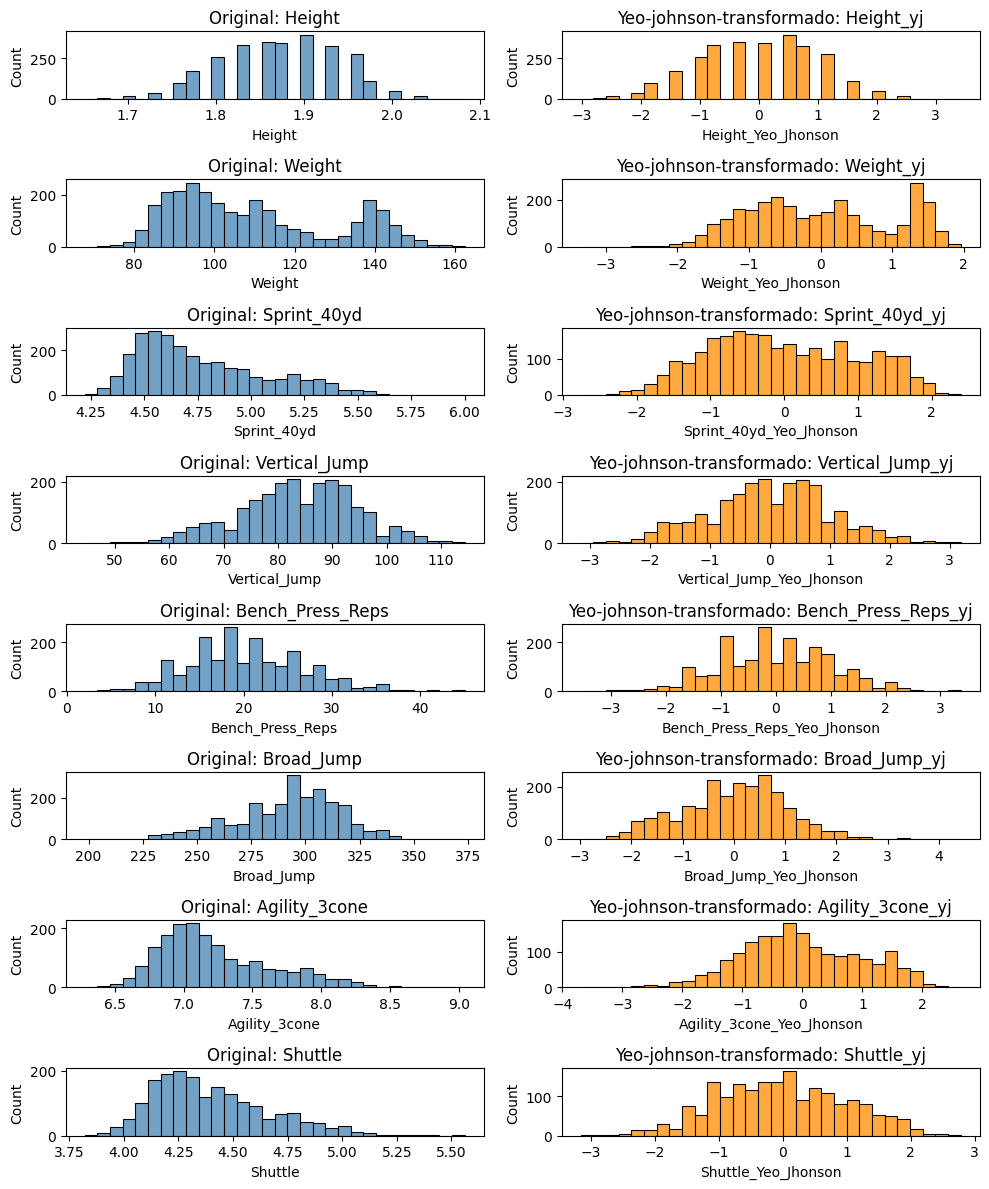

In [900]:
# Corrigieremos la asimetrica con Boxcox ya que transformando a logaritmo no se ha corregido
from sklearn.preprocessing import PowerTransformer
rs = PowerTransformer(method='yeo-johnson')
# Variables con asimetría positiva
cols_skewed = ['Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone',  'Shuttle']

# Aplicar transformación boxcox (log natural)
for col in cols_skewed:
    # Evitar errores si hay valores <= 0
    train[f'{col}_Yeo_Jhonson'] = rs.fit_transform(train[[col]]).ravel()
    test[f'{col}_Yeo_Jhonson'] = rs.fit_transform(test[[col]]).ravel()

# Visualizar antes y después
fig, axes = plt.subplots(len(cols_skewed), 2, figsize=(10, 12))
for i, col in enumerate(cols_skewed):
    sns.histplot(train[col], bins=30, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'Original: {col}')
    sns.histplot(train[f'{col}_Yeo_Jhonson'], bins=30, ax=axes[i, 1], color='darkorange')
    axes[i, 1].set_title(f'Yeo-johnson-transformado: {col}_yj')
plt.tight_layout()
plt.show()


In [901]:
train.head()

,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,...,Position,Drafted,Height_Yeo_Jhonson,Weight_Yeo_Jhonson,Sprint_40yd_Yeo_Jhonson,Vertical_Jump_Yeo_Jhonson,Bench_Press_Reps_Yeo_Jhonson,Broad_Jump_Yeo_Jhonson,Agility_3cone_Yeo_Jhonson,Shuttle_Yeo_Jhonson
0,0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,...,OG,1.0,0.443776,1.387465,1.720889,-2.080492,1.328101,-1.595634,1.515377,1.764692
1,1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,...,WR,1.0,-0.687335,-1.251435,-2.091135,1.778295,-0.627764,1.912341,NaN,NaN
2,2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,...,WR,1.0,-0.319592,-0.799655,-0.892832,0.729772,-1.700618,0.733574,-0.646381,0.030652
3,3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,...,DT,1.0,0.839695,1.629726,1.147431,-0.710738,2.637315,-1.513115,1.801975,1.190967
4,4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,...,WR,1.0,0.057396,-0.865179,-0.282303,-0.482036,NaN,-0.496468,-0.097252,-0.741260


In [902]:
# Verificar la mejora: si los valores se acercan a 0 la distribucion esta balanceada
from scipy.stats import skew
cols_yj = ['Height_Yeo_Jhonson', 'Weight_Yeo_Jhonson', 'Sprint_40yd_Yeo_Jhonson', 'Vertical_Jump_Yeo_Jhonson', 'Bench_Press_Reps_Yeo_Jhonson', 'Broad_Jump_Yeo_Jhonson', 'Agility_3cone_Yeo_Jhonson',  'Shuttle_Yeo_Jhonson']
for col in cols_yj:
    print(f"{col}: {skew(train[col].dropna()):.3f}")
    print(f"{col}: {skew(test[col].dropna()):.3f}")

Height_Yeo_Jhonson: -0.015
Height_Yeo_Jhonson: -0.016
Weight_Yeo_Jhonson: 0.075
Weight_Yeo_Jhonson: 0.089
Sprint_40yd_Yeo_Jhonson: 0.119
Sprint_40yd_Yeo_Jhonson: 0.129
Vertical_Jump_Yeo_Jhonson: -0.012
Vertical_Jump_Yeo_Jhonson: -0.014
Bench_Press_Reps_Yeo_Jhonson: -0.002
Bench_Press_Reps_Yeo_Jhonson: -0.020
Broad_Jump_Yeo_Jhonson: -0.009
Broad_Jump_Yeo_Jhonson: -0.024
Agility_3cone_Yeo_Jhonson: 0.061
Agility_3cone_Yeo_Jhonson: 0.048
Shuttle_Yeo_Jhonson: 0.047
Shuttle_Yeo_Jhonson: 0.026


In [903]:
#veamos si hay valores faltantes en esas columnas:
train.isnull().sum()

,0
Id,0
Year,0
Age,435
School,0
Height,0
Weight,0
Sprint_40yd,145
Vertical_Jump,554
Bench_Press_Reps,721
Broad_Jump,581


### [Next Steps]

EDA is open-ended; here are some directions you can take next:

- Examine the relationship between each numerical feature and the target with grouped boxplots (`sns.boxplot(x='Drafted', y=col, ...)`).
- Cross-tabulate categorical features against **Drafted** to see which categories have a high or low draft rate.
- Investigate the **School** column more carefully — for example, group schools by conference or region and check the draft rate per group.
- Look for outliers in other numerical columns (e.g. **Bench_Press_Reps**, **Vertical_Jump**) and decide how to handle them.

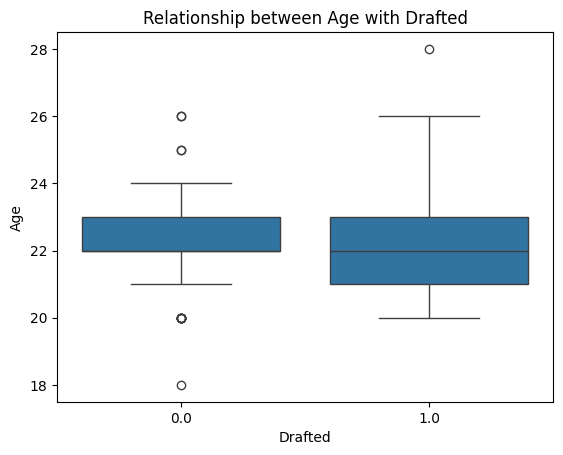

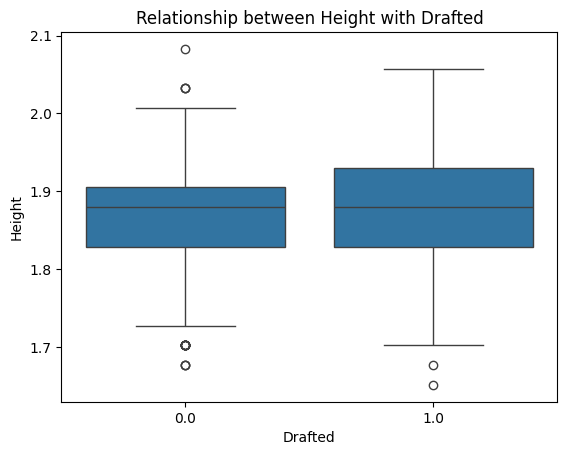

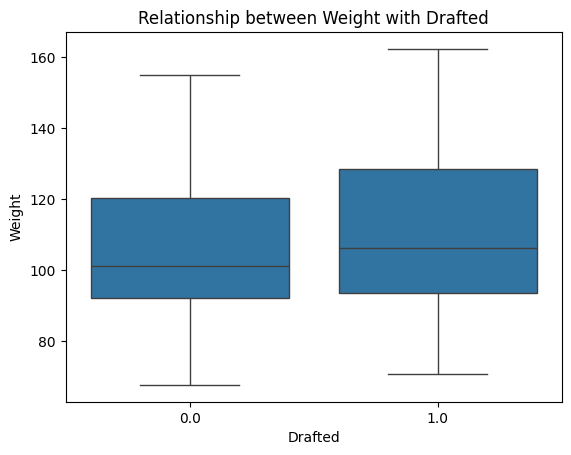

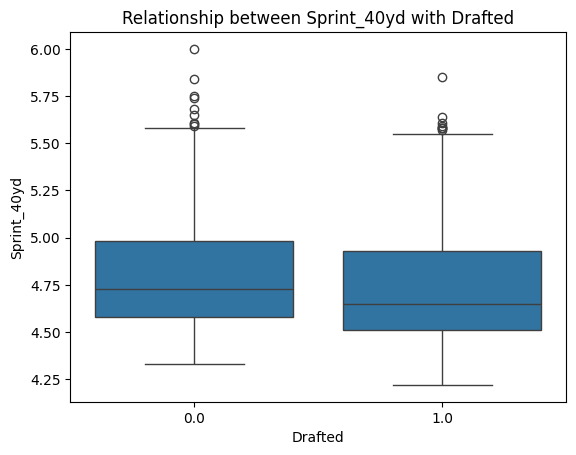

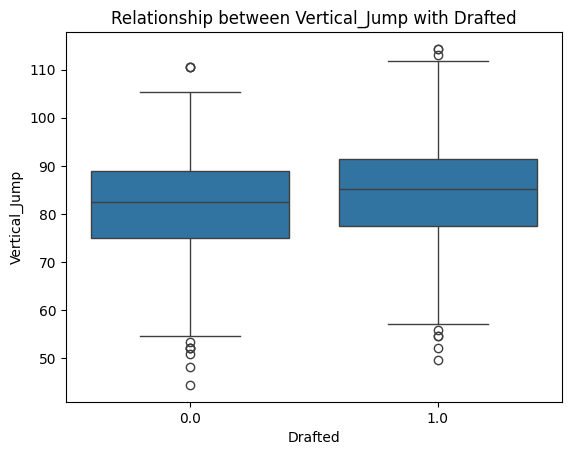

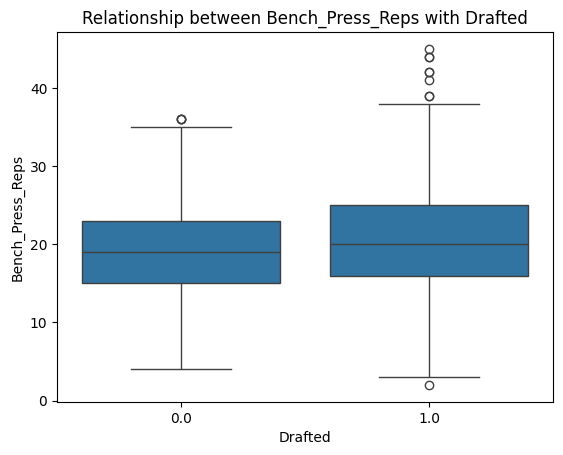

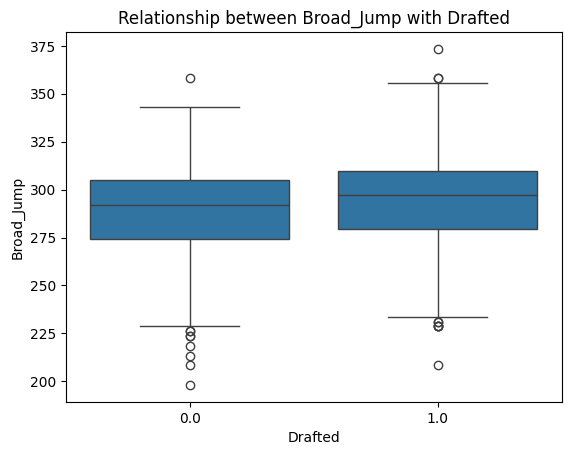

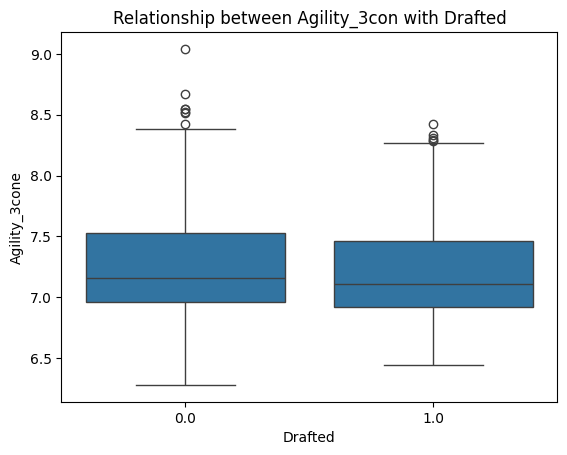

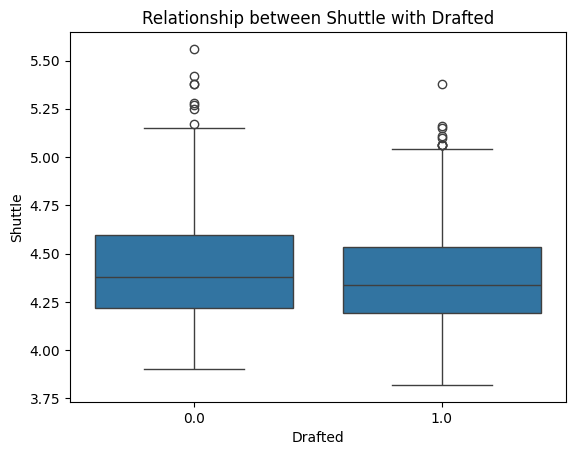

In [904]:
sns.boxplot(x='Drafted', y=('Age'), data=train)
plt.title('Relationship between Age with Drafted')
plt.show()

sns.boxplot(x='Drafted', y=('Height'), data=train)
plt.title('Relationship between Height with Drafted')
plt.show()

sns.boxplot(x='Drafted', y=('Weight'), data=train)
plt.title('Relationship between Weight with Drafted')
plt.show()

sns.boxplot(x='Drafted', y=('Sprint_40yd'), data=train)
plt.title('Relationship between Sprint_40yd with Drafted')
plt.show()

sns.boxplot(x='Drafted', y=('Vertical_Jump'), data=train)
plt.title('Relationship between Vertical_Jump with Drafted')
plt.show()

sns.boxplot(x='Drafted', y=('Bench_Press_Reps'), data=train)
plt.title('Relationship between Bench_Press_Reps with Drafted')
plt.show()

sns.boxplot(x='Drafted', y=('Broad_Jump'), data=train)
plt.title('Relationship between Broad_Jump with Drafted')
plt.show()

sns.boxplot(x='Drafted', y=('Agility_3cone'), data=train)
plt.title('Relationship between Agility_3con with Drafted')
plt.show()

sns.boxplot(x='Drafted', y=('Shuttle'), data=train)
plt.title('Relationship between Shuttle with Drafted')
plt.show()

In [905]:
# Tabla cruzada de frecuencias
tabla = pd.crosstab(train['Player_Type'], train['Drafted'], normalize='index') * 100

# Renombrar columnas para claridad
tabla.columns = ['No Drafted (%)', 'Drafted (%)']

print(tabla.sort_values('Drafted (%)', ascending=False))


               No Drafted (%)  Drafted (%)
Player_Type                               
defense             30.136986    69.863014
offense             36.955017    63.044983
special_teams       73.684211    26.315789


In [906]:
#Tasa de reclutamiento por escuela
groupby_school = train.groupby('School')['Drafted'].mean().sort_values(ascending=False)
pd.set_option('display.max_rows', None)
print(groupby_school)

School
Abilene Christian           1.000000
Ala-Birmingham              1.000000
Ashland                     1.000000
Ark-Pine Bluff              1.000000
Concordia (MN)              1.000000
Cal Poly                    1.000000
Citadel                     1.000000
Charlotte                   1.000000
Chadron St.                 1.000000
East. Illinois              1.000000
Drake                       1.000000
Delaware                    1.000000
Hobart & William Smith      1.000000
Humboldt St.                1.000000
Kutztown Pennsylvania       1.000000
Maine                       1.000000
Lindenwood                  1.000000
Louisiana-Lafayette         1.000000
Fort Hays St.               1.000000
Georgia Southern            1.000000
Florida International       1.000000
Fordham                     1.000000
Florida A&M                 1.000000
Elon                        1.000000
East Central (OK)           1.000000
Lehigh                      1.000000
Wagner                      1.0

In [907]:
#Eliminacion de outliders - se eliminara los ouliders de las siguientes variables
# Edad -- fuera de 18 y 28
#Sprynt_40yd ---- fuera 4.2s y 5.8s
#Shutle --- fuera de 4.0s y 5.3s
#Agility_3cone --- fuera de 6.4s y 8.8s pueden ser errores o inconsistencias en los datos

#Validar Rangos
"""valid_ranges = {
    "Age": (17, 30),
    "Sprint_40yd": (4.0, 6.0),
    "Shuttle": (3.5, 6.0),
    "Agility_3cone": (6.0, 9.0)
}

# Creamos un filtro para cada variable y lo aplicamos
for col, (low, high) in valid_ranges.items():
    before = train.shape[0] & test.shape[0]
    train = train[(train[col] >= low) & (train[col] <= high)]
    test = test[(test[col] >= low) & (test[col] <= high)]
    after = train.shape[0] & test.shape[0]
    print(f"{col}: eliminadas {before - after} filas fuera del rango [{low}, {high}]")

# Resultado final
print("Dataset train limpio:", train.shape)
print("Datast test limpio:", test.shape)"""

'valid_ranges = {\n    "Age": (17, 30),\n    "Sprint_40yd": (4.0, 6.0),\n    "Shuttle": (3.5, 6.0),\n    "Agility_3cone": (6.0, 9.0)\n}\n\n# Creamos un filtro para cada variable y lo aplicamos\nfor col, (low, high) in valid_ranges.items():\n    before = train.shape[0] & test.shape[0]\n    train = train[(train[col] >= low) & (train[col] <= high)]\n    test = test[(test[col] >= low) & (test[col] <= high)]\n    after = train.shape[0] & test.shape[0]\n    print(f"{col}: eliminadas {before - after} filas fuera del rango [{low}, {high}]")\n\n# Resultado final\nprint("Dataset train limpio:", train.shape)\nprint("Datast test limpio:", test.shape)'

In [908]:
train.dtypes

,0
Id,int64
Year,int64
Age,float64
School,object
Height,float64
Weight,float64
Sprint_40yd,float64
Vertical_Jump,float64
Bench_Press_Reps,float64
Broad_Jump,float64


# 4.Preprocessing

Here, we will conduct the preprocessing and create new features based on what we have learned in the preceding visualization and analysis. We will perform **missing value imputation** and **encoding**.

### 4.1 Dropping Columns

In this notebook, we will exclude categorical features with a relatively large number of unique levels. Specifically, we will drop the **School** column (**236** unique values). *(Note: School may still influence Drafted; if you want to explore further, try including it as a feature.)* We will also drop the **Id** column, since it is expected to be unrelated to whether a player is drafted.

In [909]:
# Drop unused columns
train = train.drop(columns=["Id"])
test = test.drop(columns=["Id"])

In [910]:
# Vamos a decirle al modelo, agregando columnas de valores faltantes cuales son las columnas que faltaron valores

# Columnas con valores faltantes según tu análisis
cols_with_missing = ['Age', 'Height', 'Weight', 'Sprint_40yd',
                     'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump',
                     'Agility_3cone',  'Shuttle']

# Función para agregar columnas de indicadores de missing
def add_missing_indicators(df, cols):
    for col in cols:
        df[col + '_missing'] = df[col].isna().astype(int)
    return df

# Aplicar a train y test
train = add_missing_indicators(train, cols_with_missing)
test = add_missing_indicators(test, cols_with_missing)

# Verificación rápida: contar cuántos faltantes había en cada columna
print("Train missing indicators:")
print(train[[col + '_missing' for col in cols_with_missing]].sum())

print("\nTest missing indicators:")
print(test[[col + '_missing' for col in cols_with_missing]].sum())



Train missing indicators:
Age_missing                 435
Height_missing                0
Weight_missing                0
Sprint_40yd_missing         145
Vertical_Jump_missing       554
Bench_Press_Reps_missing    721
Broad_Jump_missing          581
Agility_3cone_missing       970
Shuttle_missing             912
dtype: int64

Test missing indicators:
Age_missing                 115
Height_missing                0
Weight_missing                0
Sprint_40yd_missing          29
Vertical_Jump_missing       143
Bench_Press_Reps_missing    184
Broad_Jump_missing          147
Agility_3cone_missing       247
Shuttle_missing             228
dtype: int64


In [911]:
train.head()

,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,...,Shuttle_Yeo_Jhonson,Age_missing,Height_missing,Weight_missing,Sprint_40yd_missing,Vertical_Jump_missing,Bench_Press_Reps_missing,Broad_Jump_missing,Agility_3cone_missing,Shuttle_missing
0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,...,1.764692,0,0,0,0,0,0,0,0,0
1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,...,NaN,0,0,0,0,0,0,0,1,1
2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,...,0.030652,0,0,0,0,0,0,0,0,0
3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,...,1.190967,0,0,0,0,0,0,0,0,0
4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,...,-0.741260,0,0,0,0,0,1,0,0,0


### 4.2 Dealing Missing Values

There are missing values in **Age**, **Sprint_40yd**, **Vertical_Jump**, **Bench_Press_Reps**, **Broad_Jump**, **Agility_3cone**, and **Shuttle**. In this notebook, we will impute these missing values using the mean of each column.

In [912]:
# Columns to impute with the mean
#cols_to_fill = ['Vertical_Jump', 'Bench_Press_Reps',
#               'Broad_Jump']

#Impute both train and test using the means computed from the training data
#for col in cols_to_fill:
    #mean_value = train[col].mean()
    #train[col] = train[col].fillna(mean_value)
    #test[col] = test[col].fillna(mean_value)

# Columnas numéricas a imputar
cols_to_fill = ['Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Sprint_40yd', 'Age', 'Agility_3cone', 'Shuttle', 'Sprint_40yd_Yeo_Jhonson',
                'Agility_3cone_Yeo_Jhonson', 'Shuttle_Yeo_Jhonson', 'Vertical_Jump_Yeo_Jhonson', 'Bench_Press_Reps_Yeo_Jhonson', 'Broad_Jump_Yeo_Jhonson']

# Imputar en train con la media por posición
for col in cols_to_fill:
    train[col] = train.groupby('Position')[col].transform(
        lambda x: x.fillna(x.mean())
    )

# Calcular medias por posición en train (referencia para test)
position_means = train.groupby('Position')[cols_to_fill].mean()

# Imputar en test usando las medias de train
for col in cols_to_fill:
    test[col] = test.apply(
        lambda row: row[col] if pd.notnull(row[col])
        else position_means.loc[row['Position'], col],
        axis=1
    )

# Imputación jerárquica: si aún quedan NaN, usar la media global del train
for col in cols_to_fill:
    global_mean = train[col].mean()
    train[col] = train[col].fillna(global_mean)
    test[col] = test[col].fillna(global_mean)

Now, the missing values in both **train** and **test** have been handled.

### 4.3 Dealing Categorical Data

Next, let's convert the categorical features into numerical values so they can be used as model imputs. Most machine learning models can only accept numerical data.

Here, we will use a technique called **label encoding**.

En mi caso la codificacion de etiquetas se hizo en el apartado 4.2

In [913]:
# Label-encode the categorical features
#label_encoders = {}
#for c in ["Player_Type", "Position_Type", "Position"]:
    #label_encoders[c] = LabelEncoder()
    #train[c] = label_encoders[c].fit_transform(train[c].astype(str))
    #test[c] = label_encoders[c].transform(test[c].astype(str))

# Vamos a categorizar la variables escuela, Tipo de Jugador, Tipo de Posicion y Posicion, el tramiento que la daremos a escuela es target code
# ya que tiene 236 niveles, y por tener niveles menores al resto de variables con one-hot

#Empezamos con escuela
# Convertir todo a string para uniformidad
train["School"] = train["School"].astype(str)
test["School"]  = test["School"].astype(str)

# Calcular la tasa de selección por escuela en el conjunto de entrenamiento
school_means = train.groupby("School")["Drafted"].mean()

# Crear la nueva columna codificada en train
train["School"] = train["School"].map(school_means)

# Aplicar la misma transformación en test (usando medias de train)
test["School"] = test["School"].map(school_means)

# Si alguna escuela en test no aparece en train → usar la media global
global_mean = train["Drafted"].mean()
test["School"].fillna(global_mean, inplace=True)

/tmp/ipykernel_470/510056834.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test["School"].fillna(global_mean, inplace=True)


In [914]:
"""#Ahora utilizamos one hot para la variables Tipo de Jugador, Tipo de Posicion y Posicion
categorical_cols = ["Player_Type", "Position_Type", "Position"]

train = pd.get_dummies(train, columns=categorical_cols, drop_first=True, dtype=int)
test = pd.get_dummies(test, columns=categorical_cols, drop_first=True, dtype=int)

# Alinear columnas para que train y test tengan las mismas
train, test = train.align(test, join="left", axis=1, fill_value=0)"""

'#Ahora utilizamos one hot para la variables Tipo de Jugador, Tipo de Posicion y Posicion\ncategorical_cols = ["Player_Type", "Position_Type", "Position"]\n\ntrain = pd.get_dummies(train, columns=categorical_cols, drop_first=True, dtype=int)\ntest = pd.get_dummies(test, columns=categorical_cols, drop_first=True, dtype=int)\n\n# Alinear columnas para que train y test tengan las mismas\ntrain, test = train.align(test, join="left", axis=1, fill_value=0)'

In [915]:
#Vamos a mejorar el balance de las variables categoricas: Player_Type", "Position_Type", "Position", usando target encondig
categorical_cols = ["Player_Type", "Position_Type", "Position"]

# Calcular medias en train
target_means = {}
for col in categorical_cols:
    target_means[col] = train.groupby(col)['Drafted'].mean()
    train[col + '_enc'] = train[col].map(target_means[col])

    # Aplicar al test usando las medias de train
    test[col + '_enc'] = test[col].map(target_means[col])

    # Si hay categorías nuevas en test, reemplazar por la media global
    global_mean = train['Drafted'].mean()
    test[col + '_enc'].fillna(global_mean, inplace=True)


/tmp/ipykernel_470/1123409161.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test[col + '_enc'].fillna(global_mean, inplace=True)
/tmp/ipykernel_470/1123409161.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [916]:
#Comprobamos si el desbalance se ha corregido
# si los valores están concentrados en un rango estrecho (ej. 0.4–0.6),
#significa que las categorías tienen tasas similares de “Drafted”. Si hay valores extremos (ej. 0.1 vs 0.9), aún hay desbalance.
for col in ["Player_Type_enc", "Position_Type_enc", "Position_enc"]:
    print(col, train[col].describe())

Player_Type_enc count    2781.000000
mean        0.648328
std         0.079783
min         0.263158
25%         0.630450
50%         0.630450
75%         0.698630
max         0.698630
Name: Player_Type_enc, dtype: float64
Position_Type_enc count    2781.000000
mean        0.648328
std         0.082800
min         0.256098
25%         0.615842
50%         0.664368
75%         0.708440
max         0.728155
Name: Position_Type_enc, dtype: float64
Position_enc count    2781.000000
mean        0.648328
std         0.091455
min         0.227273
25%         0.612000
50%         0.677966
75%         0.701571
max         0.759162
Name: Position_enc, dtype: float64


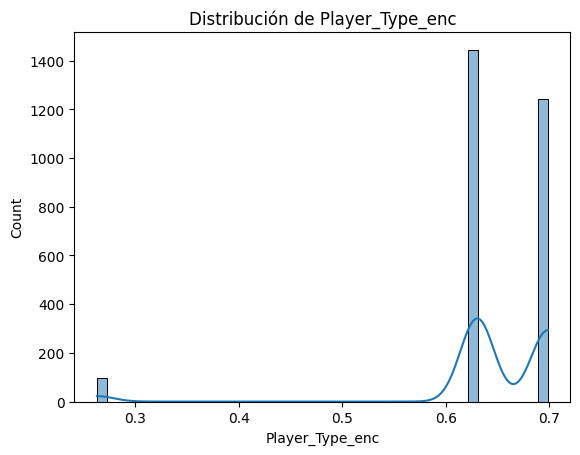

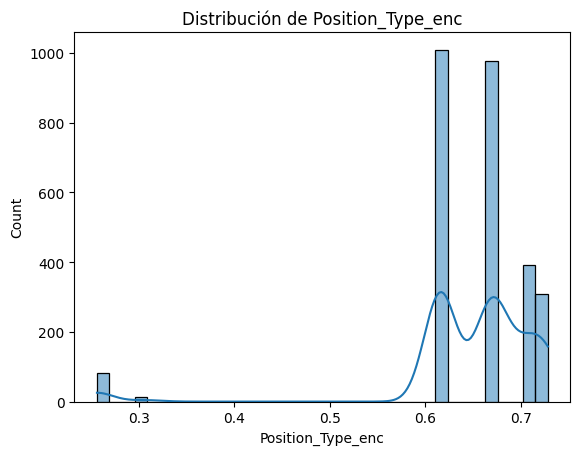

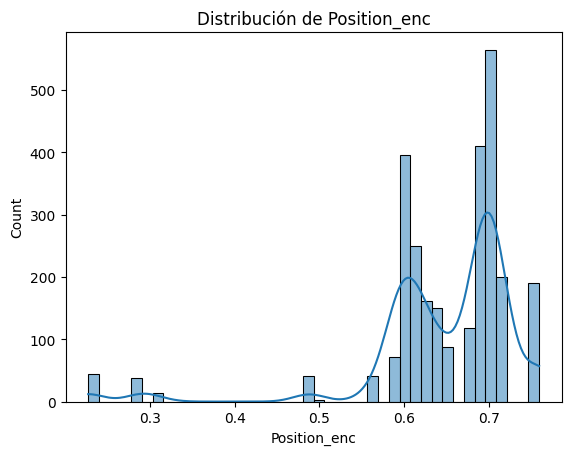

In [917]:
#Vemos graficamente si el desbalance se corrigio
for col in ["Player_Type_enc", "Position_Type_enc", "Position_enc"]:
    sns.histplot(train[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

In [918]:
#Eliminamos las columnas categoricas originales para evitar fuga de informacion
train = train.drop(columns=categorical_cols)
test = test.drop(columns=categorical_cols)

In [919]:
train.head()

,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,...,Weight_missing,Sprint_40yd_missing,Vertical_Jump_missing,Bench_Press_Reps_missing,Broad_Jump_missing,Agility_3cone_missing,Shuttle_missing,Player_Type_enc,Position_Type_enc,Position_enc
0,2011,21.0,1.000000,1.9050,140.160042,5.39,59.69,29.00000,251.46,7.91000,...,0,0,0,0,0,0,0,0.63045,0.664368,0.642384
1,2011,24.0,1.000000,1.8288,87.089735,4.31,101.60,16.00000,332.74,6.92875,...,0,0,0,0,0,1,1,0.63045,0.615842,0.594937
2,2018,21.0,0.461538,1.8542,92.986436,4.51,91.44,10.00000,309.88,6.95000,...,0,0,0,0,0,0,0,0.63045,0.615842,0.594937
3,2010,21.0,0.500000,1.9304,148.778297,5.09,76.20,39.00000,254.00,8.12000,...,0,0,0,0,0,0,0,0.69863,0.708440,0.715000
4,2016,21.0,0.741935,1.8796,92.079251,4.64,78.74,14.52443,281.94,7.13000,...,0,0,0,1,0,0,0,0.63045,0.615842,0.594937


### [Next Steps]

The preprocessing here is intentionally minimal. You can likely improve the score by changing how features are prepared:

- **Imputation**: try the median, a group-wise mean (e.g. mean by **Position**), or a model-based imputer such as `KNNImputer`.
- **Encoding**: try **One-Hot Encoding**, **Target (Mean) Encoding**, or **Frequency Encoding** instead of label encoding.
- **School**: rather than dropping it, try encoding it (e.g. target encoding or frequency encoding).
- Add a **missing-value indicator** (a 0/1 column that records whether the original value was missing).

## 5.Baseline Model

Now that the data has been prepared, we will use it as input to build a **baseline model**. A baseline model is a simple initial machine learning model that serves as a starting point.

In this notebook, we will use a **Random Forest** model, which is a tree-based method that makes predictions by combining many **decision trees**.

A decision tree is an intuitive model that repeatedly splits the data using simple “yes/no” questions. For example: “Is the player taller than 170 cm?” or “Is the player a kicker?” By following these conditions step by step, the model arrives at a final prediction.

However, using a single decision tree often leads to a model that fits the training data too closely and does not generalize well to new data—this is called **overfitting**. Random Forest addresses this by training dozens (or even hundreds) of decision trees, each on slightly different subsets of the data and features. It then combines their predictions—typically by averaging—resulting in a more stable and robust model.

To evaluate the model's performance, we will use **cross-validation**. This method splits the dataset into several groups (folds) and repeats training and evaluation multiple times.

In this notebook, we use **5-fold cross-validation**: the data is split into five folds, and each time we use one fold for validation and the remaining four folds for training. We repeat this process five times and take the average score as an estimate of model performance. Cross-validation is ueful because it provides a more reliable evaluation than a single train/validation split.

In [920]:
# Split into features and target
X = train.drop(columns=["Drafted"])
y = train["Drafted"]

# Set up the model and cross-validation
model = RandomForestClassifier(
    n_estimators=260,
    max_depth=4,
    random_state=2025
)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Store scores
auc_scores = []

# Train and evaluate using Startified K-Fold cross-validation
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # Train the model
    model.fit(X_train, y_train)

    # Predict and score
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

# Print mean AUC
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))

Fold 1
  AUC: 0.8187
Fold 2
  AUC: 0.8298
Fold 3
  AUC: 0.865
Fold 4
  AUC: 0.8584
Fold 5
  AUC: 0.8557
Fold 6
  AUC: 0.8506
Fold 7
  AUC: 0.813
Fold 8
  AUC: 0.8035
Fold 9
  AUC: 0.8528
Fold 10
  AUC: 0.8794

Average Validation AUC: 0.8427


This model achieved an AUC score of **0.8115**.

In [921]:
train.isnull().sum()

,0
Year,0
Age,0
School,0
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0
Agility_3cone,0


In [922]:
!pip install catboost
import catboost as cb
"""X = train.drop(columns=["Drafted"])
y = train["Drafted"]

# Set up the model and cross-validation
model = cb.CatBoostClassifier(
    n_estimators=260,
    max_depth=5,
    random_state=2025
)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Store scores
auc_scores = []

# Train and evaluate using Startified K-Fold cross-validation
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # Train the model
    model.fit(X_train, y_train)

    # Predict and score
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

# Print mean AUC
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))"""

'X = train.drop(columns=["Drafted"])\ny = train["Drafted"]\n\n# Set up the model and cross-validation\nmodel = cb.CatBoostClassifier(\n    n_estimators=260,\n    max_depth=5,\n    random_state=2025\n)\nskf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)\n\n# Store scores\nauc_scores = []\n\n# Train and evaluate using Startified K-Fold cross-validation\nfor fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):\n    print(f"Fold {fold + 1}")\n\n    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]\n    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]\n\n    # Train the model\n    model.fit(X_train, y_train)\n\n    # Predict and score\n    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]\n    auc = roc_auc_score(y_valid, y_valid_pred_proba)\n    auc_scores.append(auc)\n    print(f"  AUC: {round(auc, 4)}")\n\n# Print mean AUC\nmean_auc = np.mean(auc_scores)\nprint("\nAverage Validation AUC:", round(mean_auc, 4))'

In [923]:
train.isnull().sum()

,0
Year,0
Age,0
School,0
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0
Agility_3cone,0


Se probara diferente modelos y se los evaluara con validacion cruzada

In [925]:
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
import xgboost as xgb


# Features y target
X = train.drop(columns=['Drafted', 'Sprint_40yd_missing', 'Vertical_Jump_missing',
       'Bench_Press_Reps_missing', 'Broad_Jump_missing', 'Broad_Jump',
       'Agility_3cone_missing', 'Shuttle_missing'
       ])
y = train["Drafted"]

# Modelos y parámetros iniciales
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, solver="lbfgs", random_state=2025
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=200, max_depth=5, min_child_samples=20, random_state=2025
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=200, max_depth=5, min_child_weight=3,
        use_label_encoder=False, eval_metric="logloss", random_state=2025
    ),
    "CatBoost": cb.CatBoostClassifier(
        n_estimators=260, max_depth=5, random_state=2025, verbose=0
    )
}

# Validación cruzada
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    print(f"\nModelo: {name}")
    auc_scores = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model.fit(X_train, y_train)
        y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
        auc = roc_auc_score(y_valid, y_valid_pred_proba)
        auc_scores.append(auc)
        print(f"  Fold {fold+1} AUC: {round(auc, 4)}")

    mean_auc = np.mean(auc_scores)
    results[name] = mean_auc
    print(f"Average Validation AUC for {name}: {round(mean_auc, 4)}")

# Resumen final
print("\nResumen de modelos:")
for name, score in results.items():
    print(f"{name}: Mean AUC = {score:.4f}")


Modelo: Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Fold 1 AUC: 0.859


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Fold 2 AUC: 0.8572


...

  Fold 8 AUC: 0.8118


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:30:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 9 AUC: 0.8094


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:30:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 10 AUC: 0.8774
Average Validation AUC for XGBoost: 0.8311

Modelo: CatBoost
  Fold 1 AUC: 0.8445
  Fold 2 AUC: 0.8507
  Fold 3 AUC: 0.8883
  Fold 4 AUC: 0.8771
  Fold 5 AUC: 0.863
  Fold 6 AUC: 0.8744
  Fold 7 AUC: 0.8101
  Fold 8 AUC: 0.8323
  Fold 9 AUC: 0.8582
  Fold 10 AUC: 0.903
Average Validation AUC for CatBoost: 0.8602

Resumen de modelos:
Logistic Regression: Mean AUC = 0.8587
LightGBM: Mean AUC = 0.8452
XGBoost: Mean AUC = 0.8311
CatBoost: Mean AUC = 0.8602


### [Next Steps]

The baseline uses a default Random Forest. Common ways to improve from here:

- Try other models: **Logistic Regression**, **LightGBM**, **XGBoost**, or **CatBoost**.
- Tune hyperparameters such as `n_estimators`, `max_depth`, and `min_samples_leaf`. Start with a small grid and expand once you see what helps.
- Compare a few `random_state` values or change the number of folds (`n_splits`) to check that the score is stable.

## 6. Hypotheses & Feature Engineering

Here, we will perform **feature engineering**.

Feature engineering is the process of creating new features from the original data so that the model can learn more effectively. It is one of the key steps for improving model performance.

Here, based on the hypothesis that **BMI**, a measure of body composition caluculated from height and weight, may be informative for predicting draft outcomes, we will create a new feature by computing.

**BMI = weight / (height)²**

In [926]:
for df in [train, test]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)
    df['Explosividad'] = df['Broad_Jump'] / df["Vertical_Jump"]
    df['Velocidad Relativa'] = df['Height'] / df['Sprint_40yd']
    df['Fuerza Relativa'] = df['Bench_Press_Reps'] / df['Weight']
    df['EficienciaMasaVelocidad'] = df['Weight'] / df['Sprint_40yd']
    df['EficienciaSaltoAltura'] = df['Height'] / df['Broad_Jump']
    df['Indice de Explosividad'] = df['Vertical_Jump'] * df['Broad_Jump']
    df['VelocidadxAgilidad'] = df['Sprint_40yd'] * df['Agility_3cone']
    df['Indice Cambio de Direcccion'] = df['Shuttle'] * df['Agility_3cone']
    #df['Puntuación de Velocidad'] = (df['Weight'] * 200.0) / (df['Sprint_40yd'] ** 4)

In [927]:
#Agrupacion de Edad por grupo, convirtiendola en categorica
#df['Age_group'] = pd.cut(df['Age'], bins=[0,22,25,40],
                         #labels=['Young','Prime','Veteran'])

In [928]:
print(train.columns)

Index(['Year', 'Age', 'School', 'Height', 'Weight', 'Sprint_40yd',
       'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone',
       'Shuttle', 'Drafted', 'Height_Yeo_Jhonson', 'Weight_Yeo_Jhonson',
       'Sprint_40yd_Yeo_Jhonson', 'Vertical_Jump_Yeo_Jhonson',
       'Bench_Press_Reps_Yeo_Jhonson', 'Broad_Jump_Yeo_Jhonson',
       'Agility_3cone_Yeo_Jhonson', 'Shuttle_Yeo_Jhonson', 'Age_missing',
       'Height_missing', 'Weight_missing', 'Sprint_40yd_missing',
       'Vertical_Jump_missing', 'Bench_Press_Reps_missing',
       'Broad_Jump_missing', 'Agility_3cone_missing', 'Shuttle_missing',
       'Player_Type_enc', 'Position_Type_enc', 'Position_enc', 'BMI',
       'Explosividad', 'Velocidad Relativa', 'Fuerza Relativa',
       'EficienciaMasaVelocidad', 'EficienciaSaltoAltura',
       'Indice de Explosividad', 'VelocidadxAgilidad',
       'Indice Cambio de Direcccion'],
      dtype='object')


Let's re-evaluate the model, this time including the newly created feature.

In [929]:
"""import catboost as cb
# Split into features and target
X = train.drop(columns=['Drafted', 'Year', 'Height', 'Weight',
       'EficienciaSaltoAltura', 'Explosividad',
       'Sprint_40yd_missing', 'Vertical_Jump_missing',
       'Bench_Press_Reps_missing', 'Shuttle_missing', 'Broad_Jump_missing',
       'Agility_3cone_missing', 'Indice de Explosividad'
])

y = train["Drafted"]

model = cb.CatBoostClassifier(
    n_estimators=260,
    max_depth=5,
    random_state=2025
)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Store scores
auc_scores = []

# Train and evaluate using Startified K-fold cross-validation
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # Train the model
    model.fit(X_train, y_train)

    # Validation prediction & scoring
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

# Print the mean AUC
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))"""

'import catboost as cb\n# Split into features and target\nX = train.drop(columns=[\'Drafted\', \'Year\', \'Height\', \'Weight\',\n       \'EficienciaSaltoAltura\', \'Explosividad\',\n       \'Sprint_40yd_missing\', \'Vertical_Jump_missing\',\n       \'Bench_Press_Reps_missing\', \'Shuttle_missing\', \'Broad_Jump_missing\',\n       \'Agility_3cone_missing\', \'Indice de Explosividad\'\n])\n\ny = train["Drafted"]\n\nmodel = cb.CatBoostClassifier(\n    n_estimators=260,\n    max_depth=5,\n    random_state=2025\n)\nskf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)\n\n# Store scores\nauc_scores = []\n\n# Train and evaluate using Startified K-fold cross-validation\nfor fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):\n    print(f"Fold {fold + 1}")\n\n    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]\n    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]\n\n    # Train the model\n    model.fit(X_train, y_train)\n\n    # Validation prediction & scorin

With feature engineering, the AUC score improved from **0.8115** to **0.813**.

As shown here, adding new features can sometimes have a positive impact on model performance. Try forming your own hypotheses and creating additional features based on the structure and meaning of the data.

Some machine learning models can compute the importance of the input features. Let's visualize the feature importances.

In [ ]:
"""# Split into features and target
X = train.drop(columns=['Drafted', 'Year', 'Height', 'Weight',
       'Drafted', 'EficienciaSaltoAltura',
       'Sprint_40yd_missing', 'Vertical_Jump_missing',
       'Bench_Press_Reps_missing', 'Shuttle_missing', 'Broad_Jump_missing',
       'Agility_3cone_missing', 'Indice de Explosividad'])

y = train["Drafted"]

# Set up the model and cross-validation
model = RandomForestClassifier(
    n_estimators=250,
    max_depth=5,
    random_state=2025
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store scores
auc_scores = []

# Train and evaluate using Startified K-Fold cross-validation
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # Train the model
    model.fit(X_train, y_train)

    # Predict and score
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

# Print mean AUC
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))"""

In [931]:
#!pip install optuna
import optuna

# Features y target
X = train.drop(columns=['Drafted', 'Year', 'Height', 'Weight',
       'Drafted', 'EficienciaSaltoAltura', 'Explosividad',
       'Sprint_40yd_missing', 'Vertical_Jump_missing',
       'Bench_Press_Reps_missing', 'Shuttle_missing', 'Broad_Jump_missing',
       'Agility_3cone_missing', 'Indice de Explosividad'])

y = train["Drafted"]

# Validación cruzada
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Función objetivo para Optuna
def objective(trial):
    model_name = trial.suggest_categorical("model", ["Logistic Regression", "LightGBM", "XGBoost", "CatBoost"])

    if model_name == "Logistic Regression":
        C = trial.suggest_float("C", 0.01, 10.0, log=True)
        model = LogisticRegression(
            C=C, max_iter=1000, solver="lbfgs", random_state=2025
        )

    elif model_name == "LightGBM":
        n_estimators = trial.suggest_int("n_estimators", 100, 500)
        max_depth = trial.suggest_int("max_depth", 3, 10)
        min_child_samples = trial.suggest_int("min_child_samples", 5, 30)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3)
        model = lgb.LGBMClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_child_samples=min_child_samples,
            learning_rate=learning_rate,
            random_state=2025
        )

    elif model_name == "XGBoost":
        n_estimators = trial.suggest_int("n_estimators", 100, 500)
        max_depth = trial.suggest_int("max_depth", 3, 10)
        min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3)
        model = xgb.XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_child_weight=min_child_weight,
            learning_rate=learning_rate,
            use_label_encoder=False,
            eval_metric="logloss",
            random_state=2025
        )

    elif model_name == "CatBoost":
        n_estimators = trial.suggest_int("n_estimators", 100, 500)
        max_depth = trial.suggest_int("max_depth", 3, 10)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3)
        model = cb.CatBoostClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            random_state=2025,
            verbose=0
        )

    # Validación cruzada
    auc_scores = []
    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model.fit(X_train, y_train)
        y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
        auc = roc_auc_score(y_valid, y_valid_pred_proba)
        auc_scores.append(auc)

    return np.mean(auc_scores)

# Ejecutar la optimización
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Mejores hiperparámetros encontrados:")
print(study.best_params)
print("Mejor AUC:", study.best_value)

[I 2026-06-11 22:31:35,665] A new study created in memory with name: no-name-068e7433-6f54-49eb-9c10-618145eb2ab8


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1622, number of negative: 880
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001412 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3144
[LightGBM] [Info] Number of data points in the train set: 2502, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.648281 -> initscore=0.611493
[LightGBM] [Info] Start training from score 0.611493
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[I 2026-06-11 22:31:46,116] Trial 0 finished with value: 0.8297159388332425 and parameters: {'model': 'LightGBM', 'n_estimators': 381, 'max_depth': 5, 'min_child_samples': 10, 'learning_rate': 0.21553997982219292}. Best is trial 0 with value: 0.8297159388332425.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1622, number of negative: 880
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001291 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3144
[LightGBM] [Info] Number of data points in the train set: 2502, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.648281 -> initscore=0.611493
[LightGBM] [Info] Start training from score 0.611493
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[I 2026-06-11 22:31:56,521] Trial 2 finished with value: 0.8289231078507233 and parameters: {'model': 'LightGBM', 'n_estimators': 259, 'max_depth': 8, 'min_child_samples': 27, 'learning_rate': 0.18311758424577199}. Best is trial 1 with value: 0.856919209501879.


...

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1622, number of negative: 880
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000254 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3144
[LightGBM] [Info] Number of data points in the train set: 2502, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.648281 -> initscore=0.611493
[LightGBM] [Info] Start training from score 0.611493
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

[I 2026-06-11 22:40:57,210] Trial 37 finished with value: 0.8362387627109472 and parameters: {'model': 'LightGBM', 'n_estimators': 317, 'max_depth': 4, 'min_child_samples': 20, 'learning_rate': 0.12241080415455971}. Best is trial 10 with value: 0.8606589679975958.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-06-11 22:41:12,500] Trial 38 finished with value: 0.8447698426259684 and parameters: {'model': 'CatBoost', 'n_estimators': 160, 'max_depth': 7, 'learning_rate': 0.1745164867072517}. Best is trial 10 with value: 0.8606589679975958.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as sh

Mejores hiperparámetros encontrados:
{'model': 'Logistic Regression', 'C': 9.072490337950658}
Mejor AUC: 0.8606589679975958


In [932]:
# Modelos base con hiperparámetros optimizados de Optuna
from sklearn.ensemble import StackingClassifier
base_models = [
    ("LightGBM", lgb.LGBMClassifier(
        n_estimators=study.best_params.get("n_estimators", 456),
        max_depth=study.best_params.get("max_depth", 3),
        min_child_samples=study.best_params.get("min_child_samples", 20),
        learning_rate=study.best_params.get("learning_rate", 0.0186473409604749),
        random_state=2025
    )),
    ("XGBoost", xgb.XGBClassifier(
        n_estimators=study.best_params.get("n_estimators", 456),
        max_depth=study.best_params.get("max_depth", 3),
        min_child_weight=study.best_params.get("min_child_weight", 3),
        learning_rate=study.best_params.get("learning_rate", 0.0186473409604749),
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=2025
    )),
    ("CatBoost", cb.CatBoostClassifier(
        n_estimators=study.best_params.get("n_estimators", 456),
        max_depth=study.best_params.get("max_depth", 3),
        learning_rate=study.best_params.get("learning_rate", 0.0186473409604749),
        random_state=2025,
        verbose=0
    ))
]

# Meta-modelo
meta_model = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=2025)

# Stacking ensemble
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1
)

# Validación cruzada externa
auc_scores = []
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    stacking_clf.fit(X_train, y_train)
    y_valid_pred_proba = stacking_clf.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"Fold {fold+1} AUC: {round(auc, 4)}")

print("\nMean AUC Stacking Ensemble:", np.mean(auc_scores))


Fold 1 AUC: 0.8548
Fold 2 AUC: 0.8501
Fold 3 AUC: 0.8867
Fold 4 AUC: 0.8717
Fold 5 AUC: 0.8629
Fold 6 AUC: 0.8759
Fold 7 AUC: 0.8205
Fold 8 AUC: 0.8342
Fold 9 AUC: 0.859
Fold 10 AUC: 0.893

Mean AUC Stacking Ensemble: 0.8608638106758718


In [936]:
# Features y target
X = train.drop(columns=['Drafted', 'Year', 'Height', 'Weight',
       'EficienciaSaltoAltura', 'Explosividad', 'Weight_missing',
       'Sprint_40yd_missing', 'Vertical_Jump_missing', 'Height_missing',
       'Bench_Press_Reps_missing', 'Shuttle_missing', 'Broad_Jump_missing',
       'Agility_3cone_missing', 'Indice de Explosividad'
])
y = train["Drafted"]

# Modelos y parámetros iniciales
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, solver="lbfgs", random_state=2025
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=200, max_depth=5, min_child_samples=20, random_state=2025
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=200, max_depth=5, min_child_weight=3,
        use_label_encoder=False, eval_metric="logloss", random_state=2025
    ),
    "CatBoost": cb.CatBoostClassifier(
        n_estimators=152, max_depth=5, random_state=2025, verbose=0
    )
}

# Validación cruzada
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    print(f"\nModelo: {name}")
    auc_scores = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model.fit(X_train, y_train)
        y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
        auc = roc_auc_score(y_valid, y_valid_pred_proba)
        auc_scores.append(auc)
        print(f"  Fold {fold+1} AUC: {round(auc, 4)}")

    mean_auc = np.mean(auc_scores)
    results[name] = mean_auc
    print(f"Average Validation AUC for {name}: {round(mean_auc, 4)}")

# Resumen final
print("\nResumen de modelos:")
for name, score in results.items():
    print(f"{name}: Mean AUC = {score:.4f}")


Modelo: Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Fold 1 AUC: 0.8584


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Fold 2 AUC: 0.8546


...

  Fold 8 AUC: 0.8162


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:50:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 9 AUC: 0.8235


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:50:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 10 AUC: 0.8649
Average Validation AUC for XGBoost: 0.8317

Modelo: CatBoost
  Fold 1 AUC: 0.8565
  Fold 2 AUC: 0.8494
  Fold 3 AUC: 0.8906
  Fold 4 AUC: 0.8725
  Fold 5 AUC: 0.8535
  Fold 6 AUC: 0.8613
  Fold 7 AUC: 0.8041
  Fold 8 AUC: 0.8481
  Fold 9 AUC: 0.8573
  Fold 10 AUC: 0.8929
Average Validation AUC for CatBoost: 0.8586

Resumen de modelos:
Logistic Regression: Mean AUC = 0.8592
LightGBM: Mean AUC = 0.8411
XGBoost: Mean AUC = 0.8317
CatBoost: Mean AUC = 0.8586


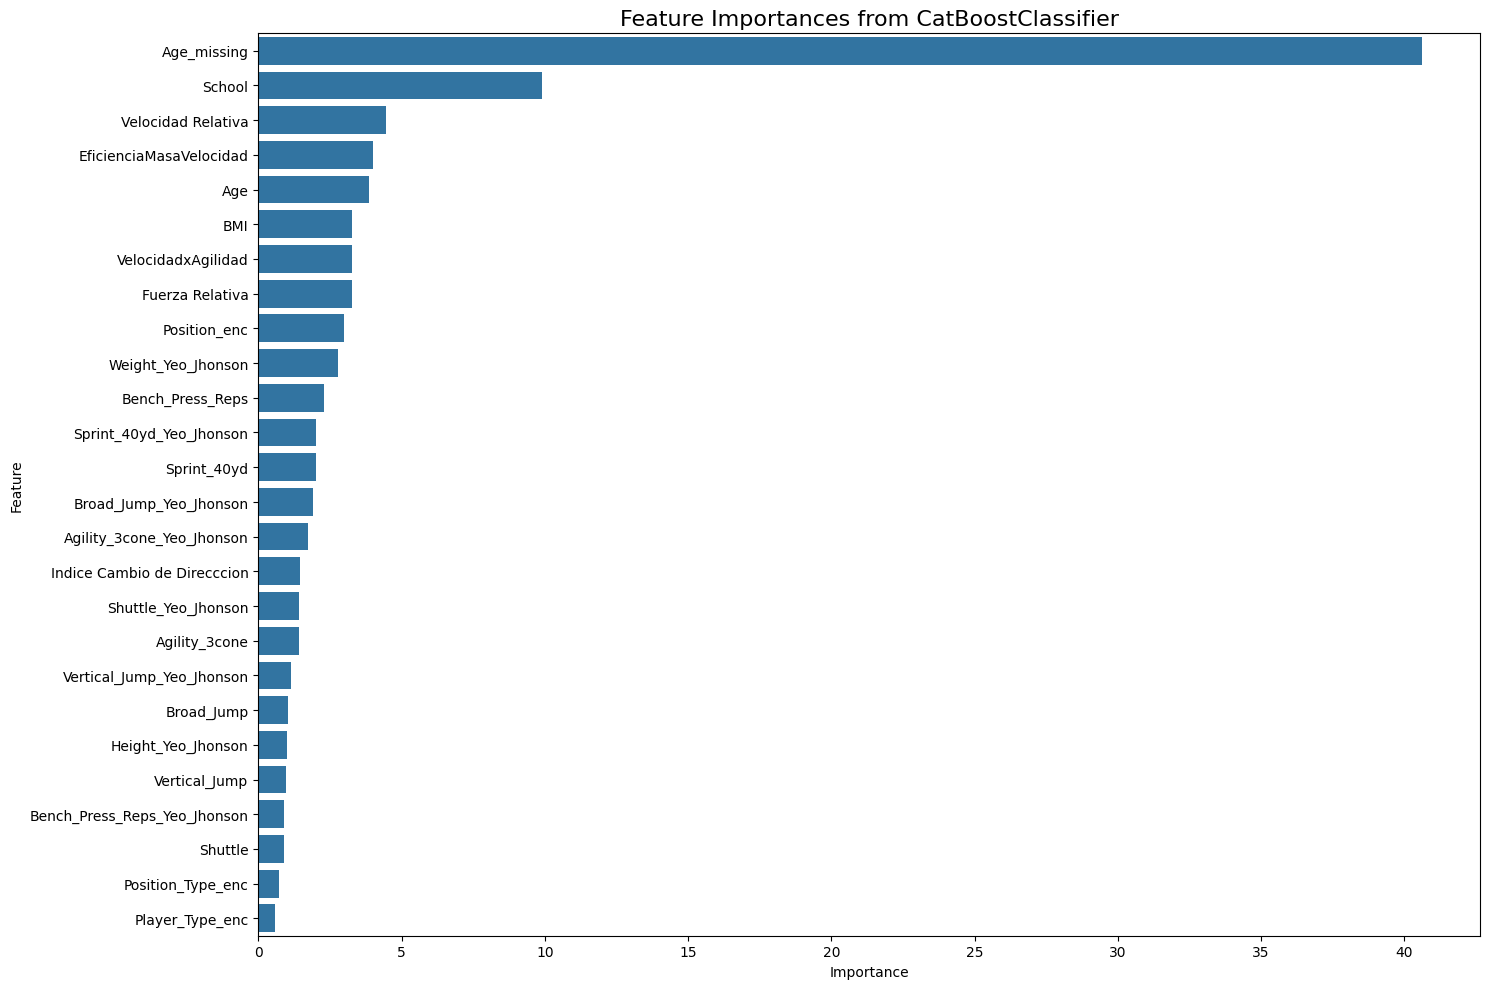

In [937]:
# Create a DataFrame of features and their importances
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualize
plt.figure(figsize=(15, 10))
sns.barplot(data=feature_importances, x='Importance', y='Feature')
plt.title('Feature Importances from CatBoostClassifier', fontsize=16)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The newly created feature, **BMI**, showed relatively high feature importance.

### [Next Steps]

We added only **BMI**. Many more features can be designed from this dataset:

- Build domain-driven features: ratios such as `Weight / Sprint_40yd`, or **Position**-specific summaries.
- Create interaction features between physical tests (e.g. `Vertical_Jump × Broad_Jump`).
- Use the feature-importance plot above to decide which features to keep, drop, or transform.
- Try binning numerical variables (e.g. **Age** into ranges) and treating them as categorical.

## 7.Create the Submission File

Finally, let's make a prediction for the test data, and prepare a CSV file to submit.

### 7.1 Predicting on the test data
We found in Sections 5 and 6 that the best model was Random Forest model with BMI column added. Therefore, we will use this model to make the final prediction.

If you made any changes and found a better model, you will need to change the code below accordingly.

In [ ]:
"""from catboost import CatBoostClassifier
# Store predictions
test_pred_proba_list = []

# Train and evaluate using Startified K-fold cross-validation
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # Train the model on this fold
    model = CatBoostClassifier(
        n_estimators=152,
        max_depth=5,
        random_state=2025,
        verbose=False
    )

    model.fit(X_train, y_train)

    # Save predictions for the test set
    test_pred_proba = model.predict_proba(test)[:, 1]
    test_pred_proba_list.append(test_pred_proba)

# Average test predictions across folds
test_pred_proba_mean = np.mean(test_pred_proba_list, axis=0)"""

In [938]:
from catboost import CatBoostClassifier

# Store predictions
test_pred_proba_list = []

# Train and evaluate using Startified K-fold cross-validation
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # Entrenar el modelo con los hiperparámetros óptimos
    model = CatBoostClassifier(
        n_estimators=456,              # Optuna
        max_depth=3,                   # Optuna
        learning_rate=0.0186473409604749,  # Optuna
        random_state=2025,
        verbose=False
    )

    model.fit(X_train, y_train)

    # Guardar predicciones para el test set
    test_pred_proba = model.predict_proba(test)[:, 1]
    test_pred_proba_list.append(test_pred_proba)

# Promedio de predicciones en test
test_pred_proba_mean = np.mean(test_pred_proba_list, axis=0)

print("Predicciones promedio en test:", test_pred_proba_mean[:10])  # muestra primeras 10


Predicciones promedio en test: [0.38462921 0.8769703  0.8660858  0.93737785 0.82533707 0.51927428
 0.15265124 0.63562058 0.67375131 0.92047359]


### 7.2 Saving the prediction as CSV file [DO NOT CHANGE]
**WARNING**: DO **NOT** CHANGE THE CODES BELOW!!!

In [939]:
# Running this cell will generate the submission CSV file
submission = pd.read_csv(PATH / 'sample_submission.csv') # Update PATH in needed
submission["Drafted"] = test_pred_proba_mean
submission.to_csv(PATH / 'submission.csv', index=False)

At this point, you have successfully created a prediction CSV file that is ready for submission. Try submitting **submission.csv**.

## 8.Next Steps

In this notebook, we built a baseline model end to end—from preprocessing and feature engineering to model training and evaluation.

From here, you can use this baseline as a foundation and aim for higher accuracy by designing more advanced features and improving the modeling approach. For example, you might explore the following:

- Try different encoding methods for categorical features
- Try alternative missing-value imputation strategies
- Experiment with other models
- Tune model hyperparameters
- Develop additional feature engineering ideas

Let’s work toward a higher score!